<a href="https://colab.research.google.com/github/Joel-Roy-2004/House_pricising/blob/main/Case_study_Ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Library

In [277]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
#imputers
from sklearn.impute import KNNImputer,SimpleImputer

# Load Dataset

In [278]:
df=pd.read_csv("/content/drive/MyDrive/AIML python/House_Pricing (1).csv")

In [279]:
df.head()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,7129300520,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,...,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,6414100192,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,...,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,5631500400,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,...,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,2487200875,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,...,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,1954400510,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,...,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


In [280]:
df.tail()

,ID,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,...,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
21608,263000018,14 May 2017,360000.0,3,2.50,1530.0,1131.0,3.0,No,NaN,...,8,1530.0,0,9,0,98103.0,47.6993,-122.346,1530.0,1509
21609,6600060120,15 February 2016,400000.0,4,2.50,2310.0,5813.0,2.0,No,NaN,...,8,2310.0,0,4,0,98146.0,47.5107,-122.362,1830.0,7200
21610,1523300141,14 June 2017,402101.0,2,0.75,1020.0,1350.0,2.0,No,NaN,...,7,1020.0,0,9,0,98144.0,47.5944,-122.299,1020.0,2007
21611,291310100,15 January 2016,400000.0,3,2.50,1600.0,2388.0,2.0,No,NaN,...,8,1600.0,0,14,0,98027.0,47.5345,-122.069,1410.0,1287
21612,1523300157,14 October 2017,325000.0,2,0.75,1020.0,1076.0,2.0,No,NaN,...,7,1020.0,0,10,0,98144.0,47.5941,-122.299,1020.0,1357


# Data Analysis

In [281]:
# Distribution of data
df.describe()

,ID,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
count,2.161300e+04,2.160900e+04,21613.000000,21609.000000,21604.000000,2.160400e+04,21613.000000,21613.000000,21610.000000,21613.000000,21613.000000,21613.000000,21612.000000,21612.000000,21612.000000,21612.000000,21613.000000
mean,4.580302e+09,5.401984e+05,3.370842,2.114732,2079.931772,1.510776e+04,1.494309,7.623467,1788.344193,291.509045,46.994864,84.402258,98077.937766,47.560048,-122.213892,1986.538914,12768.455652
std,2.876566e+09,3.673890e+05,0.930062,0.770138,918.487597,4.142827e+04,0.539989,1.105439,827.982604,442.575043,29.373411,401.679240,53.505425,0.138565,0.140830,685.404255,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,1.000000,290.000000,0.000000,3.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1429.250000,5.040000e+03,1.000000,7.000000,1190.000000,0.000000,21.000000,0.000000,98033.000000,47.470975,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.617500e+03,1.500000,7.000000,1560.000000,0.000000,43.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068825e+04,2.000000,8.000000,2210.000000,560.000000,67.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,10.000000,9410.000000,4820.000000,118.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [282]:
# Datatypes of dataframe

df.dtypes

,0
ID,int64
Date House was Sold,object
Sale Price,float64
No of Bedrooms,int64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Waterfront View,object
No of Times Visited,object


In [283]:
df = df.drop('ID', axis = 1)

In [284]:
df.head()

,Date House was Sold,Sale Price,No of Bedrooms,No of Bathrooms,Flat Area (in Sqft),Lot Area (in Sqft),No of Floors,Waterfront View,No of Times Visited,Condition of the House,Overall Grade,Area of the House from Basement (in Sqft),Basement Area (in Sqft),Age of House (in Years),Renovated Year,Zipcode,Latitude,Longitude,Living Area after Renovation (in Sqft),Lot Area after Renovation (in Sqft)
0,14 October 2017,221900.0,3,1.00,1180.0,5650.0,1.0,No,NaN,Fair,7,1180.0,0,63,0,98178.0,47.5112,-122.257,1340.0,5650
1,14 December 2017,538000.0,3,2.25,2570.0,7242.0,2.0,No,NaN,Fair,7,2170.0,400,67,1991,98125.0,47.7210,-122.319,1690.0,7639
2,15 February 2016,180000.0,2,1.00,770.0,10000.0,1.0,No,NaN,Fair,6,770.0,0,85,0,98028.0,47.7379,-122.233,2720.0,8062
3,14 December 2017,604000.0,4,3.00,1960.0,5000.0,1.0,No,NaN,Excellent,7,1050.0,910,53,0,98136.0,47.5208,-122.393,1360.0,5000
4,15 February 2016,510000.0,3,2.00,1680.0,8080.0,1.0,No,NaN,Fair,8,1680.0,0,31,0,98074.0,47.6168,-122.045,1800.0,7503


# Duplicate Removal

In [285]:
df.duplicated().sum()

np.int64(2)

In [286]:
df.drop_duplicates()
df.duplicated().sum()

np.int64(2)

# Handling Missing Values

In [287]:
df.isnull().sum()

,0
Date House was Sold,0
Sale Price,4
No of Bedrooms,0
No of Bathrooms,4
Flat Area (in Sqft),9
Lot Area (in Sqft),9
No of Floors,0
Waterfront View,0
No of Times Visited,19489
Condition of the House,0


In [288]:
(df.isnull().sum()/len(df))*100

,0
Date House was Sold,0.000000
Sale Price,0.018507
No of Bedrooms,0.000000
No of Bathrooms,0.018507
Flat Area (in Sqft),0.041642
Lot Area (in Sqft),0.041642
No of Floors,0.000000
Waterfront View,0.000000
No of Times Visited,90.172581
Condition of the House,0.000000


In [289]:
df.dropna(subset=["No of Times Visited"],inplace=True)

**Fill Missing Values Using Imputer**



# Simple Imputer

In [290]:
simple_imputer=SimpleImputer(strategy="most_frequent")

In [291]:
df_cat=df.select_dtypes(include="object")

In [292]:
df_cat_impute=pd.DataFrame(simple_imputer.fit_transform(df_cat),columns=df_cat.columns,index=df_cat.index )

In [293]:
df_cat_impute.isna().sum()

,0
Date House was Sold,0
Waterfront View,0
No of Times Visited,0
Condition of the House,0


*KNNImputer-For Numerical Values*

In [294]:
KNN_imputer=KNNImputer()

In [295]:
df_num=df.select_dtypes(exclude="object")

In [296]:
df_num_impute=pd.DataFrame(KNN_imputer.fit_transform(df_num),columns=df_num.columns,index=df_num.index)

In [297]:
df_num_impute.isna().sum()

,0
Sale Price,0
No of Bedrooms,0
No of Bathrooms,0
Flat Area (in Sqft),0
Lot Area (in Sqft),0
No of Floors,0
Overall Grade,0
Area of the House from Basement (in Sqft),0
Basement Area (in Sqft),0
Age of House (in Years),0


*concat both*

In [298]:
df_imputed = pd.concat([df_cat_impute,df_num_impute], axis=1)

# Encoded the Data

In [299]:
df_imputed.dtypes

,0
Date House was Sold,object
Waterfront View,object
No of Times Visited,object
Condition of the House,object
Sale Price,float64
No of Bedrooms,float64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64


In [300]:
#convert to date time format

df_imputed['Date House was Sold'] = pd.to_datetime(df_imputed['Date House was Sold'])

convert to int *type*

In [301]:
df_imputed['Date House was Sold'] = df_imputed['Date House was Sold'].astype('int64')

In [302]:
df_imputed.drop(columns="No of Times Visited",inplace=True)
df_imputed.columns

Index(['Date House was Sold', 'Waterfront View', 'Condition of the House',
       'Sale Price', 'No of Bedrooms', 'No of Bathrooms',
       'Flat Area (in Sqft)', 'Lot Area (in Sqft)', 'No of Floors',
       'Overall Grade', 'Area of the House from Basement (in Sqft)',
       'Basement Area (in Sqft)', 'Age of House (in Years)', 'Renovated Year',
       'Zipcode', 'Latitude', 'Longitude',
       'Living Area after Renovation (in Sqft)',
       'Lot Area after Renovation (in Sqft)'],
      dtype='object')

**Label Encoder**

In [303]:
lb=LabelEncoder()

In [304]:
cols_encode=["Condition of the House","Waterfront View"]

In [305]:
for col in cols_encode:
  df_imputed[col]=lb.fit_transform(df[col])
df_imputed.dtypes

,0
Date House was Sold,int64
Waterfront View,int64
Condition of the House,int64
Sale Price,float64
No of Bedrooms,float64
No of Bathrooms,float64
Flat Area (in Sqft),float64
Lot Area (in Sqft),float64
No of Floors,float64
Overall Grade,float64


## *Feature Engineeering/Extraction*

### *Correlation matrix*

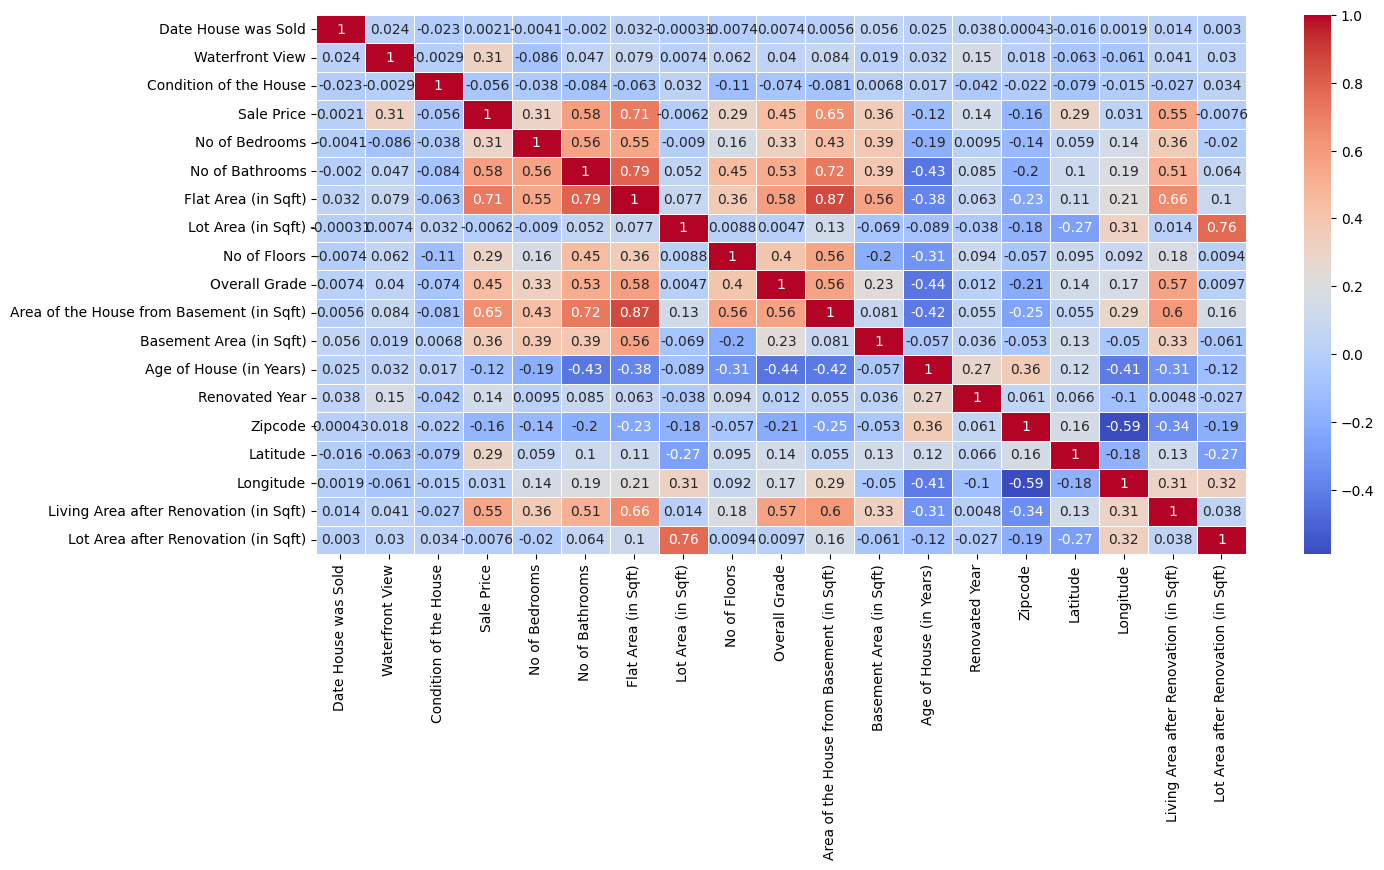

In [306]:
corr_result=df_imputed.corr()
plt.figure(figsize=(15,7))
sns.heatmap(data=corr_result,cmap="coolwarm",annot=True,linewidths=0.5)
plt.show()

In [307]:
#My target is Saleprice
#My absolute value is .7
corr_columns=["Flat Area (in Sqft)","Living Area after Renovation (in Sqft)","Area of the House from Basement (in Sqft)","Sale Price"]

In [308]:
#Remove other
df_imputed.drop(columns=df_imputed.columns.difference(corr_columns),inplace=True)


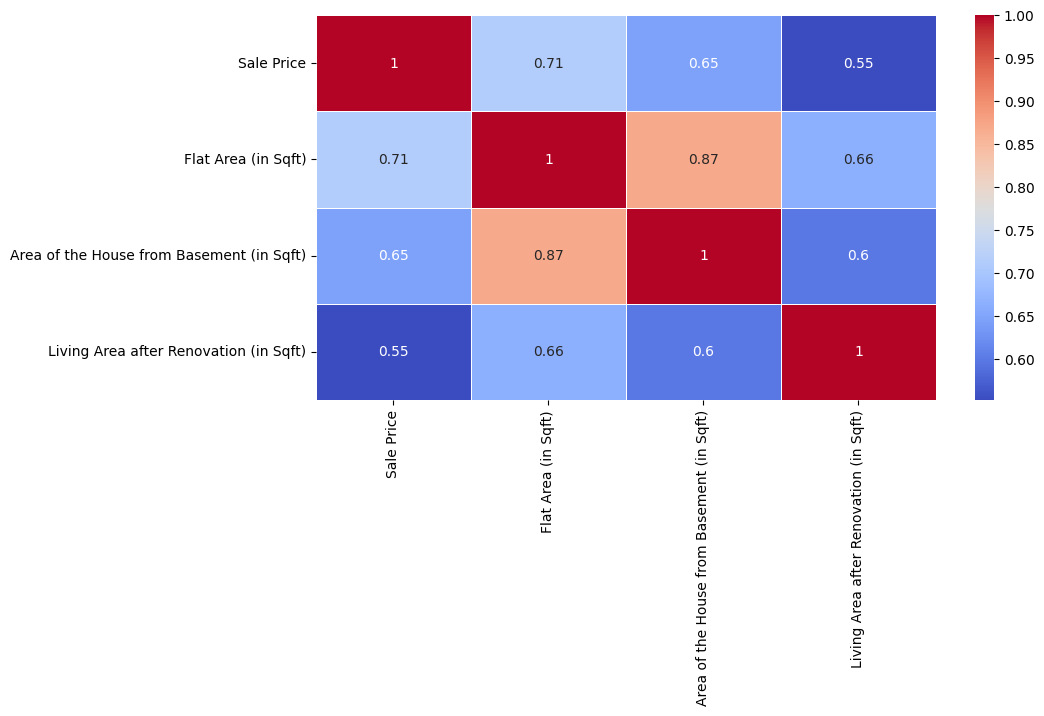

In [309]:
corr_result=df_imputed.corr()
plt.figure(figsize=(10,5))
sns.heatmap(data=corr_result,cmap="coolwarm",annot=True,linewidths=0.5)
plt.show()


# *Outlier Removal*

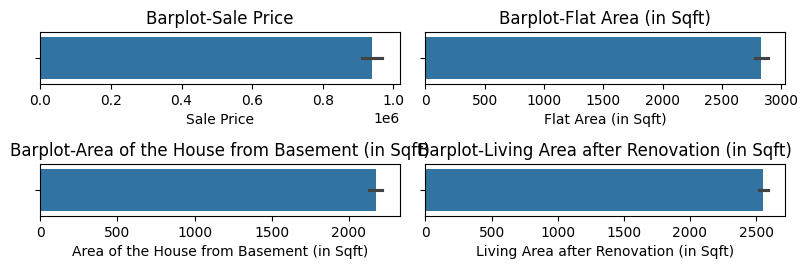

In [310]:
plt.figure(figsize=(8,5))
columns=df_imputed.columns

for i,col in enumerate(columns):
  plt.subplot(len(columns),2,i+1)
  sns.barplot(x=df[col])
  plt.title(f"Barplot-{col}")
plt.tight_layout()
plt.show()

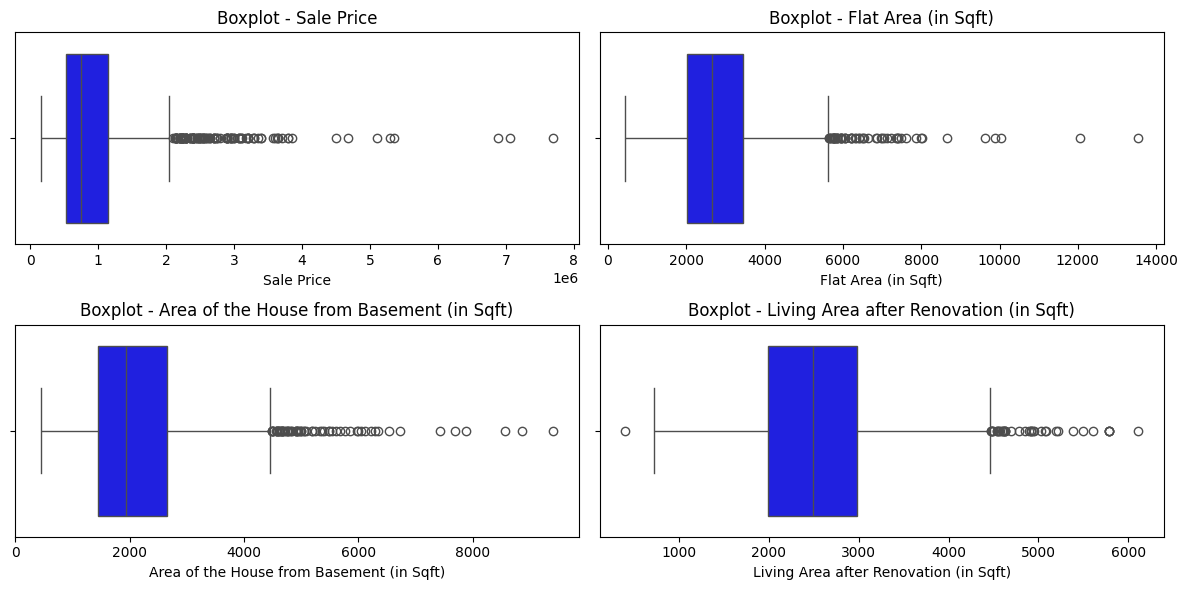

In [311]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

columns = df_imputed.columns
num_cols = len(columns)

# Set grid size (e.g., 2 columns per row)
n_cols = 2
n_rows = math.ceil(num_cols / n_cols)

# Scale figure size dynamically based on the number of rows
plt.figure(figsize=(12, 3 * n_rows))

for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1)

    # Use boxplot to highlight outliers (represented as individual dots)
    sns.boxplot(x=df_imputed[col], color='blue')
    plt.title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()

## *Fixing Outliers*

In [312]:
df_imputed.columns

Index(['Sale Price', 'Flat Area (in Sqft)',
       'Area of the House from Basement (in Sqft)',
       'Living Area after Renovation (in Sqft)'],
      dtype='object')

In [313]:
#fixing the outliers

cols_with_outliers=['Sale Price', 'Flat Area (in Sqft)',
       'Area of the House from Basement (in Sqft)',
       'Living Area after Renovation (in Sqft)']

In [314]:
def fixCols():
  for col in cols_with_outliers:
    Q1=df_imputed[col].quantile(.25)
    Q3=df_imputed[col].quantile(.75)

    IQR=Q3-Q1

    upper_bound=Q3+1.5*IQR
    lower_bound=Q1-1.5*IQR

    initial_outlier=df_imputed[(df_imputed[col]<lower_bound)|(df_imputed[col]>upper_bound)]

    print(f"Outliers in {col} before treatment:",initial_outlier[col].count())
    print("Treating Outliers...")
    df_imputed[col]=df_imputed[col].clip(upper=upper_bound,lower=lower_bound)
    final_outlier=df_imputed[(df_imputed[col]<lower_bound)|(df_imputed[col]>upper_bound)]
    print(f"Outliers in {col} after treatment:",final_outlier[col].count())

fixCols()

Outliers in Sale Price before treatment: 124
Treating Outliers...
Outliers in Sale Price after treatment: 0
Outliers in Flat Area (in Sqft) before treatment: 59
Treating Outliers...
Outliers in Flat Area (in Sqft) after treatment: 0
Outliers in Area of the House from Basement (in Sqft) before treatment: 68
Treating Outliers...
Outliers in Area of the House from Basement (in Sqft) after treatment: 0
Outliers in Living Area after Renovation (in Sqft) before treatment: 40
Treating Outliers...
Outliers in Living Area after Renovation (in Sqft) after treatment: 0


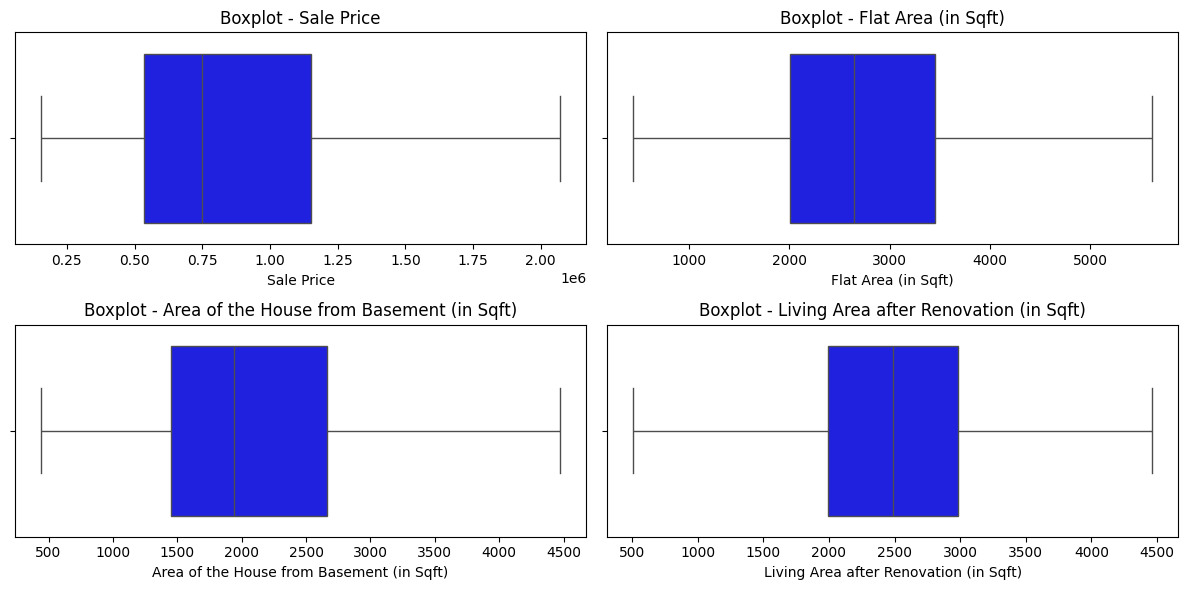

In [315]:

import matplotlib.pyplot as plt
import seaborn as sns
import math

columns = df_imputed.columns
num_cols = len(columns)

# Set grid size (e.g., 2 columns per row)
n_cols = 2
n_rows = math.ceil(num_cols / n_cols)

# Scale figure size dynamically based on the number of rows
plt.figure(figsize=(12, 3 * n_rows))

for i, col in enumerate(columns):
    plt.subplot(n_rows, n_cols, i + 1)

    # Use boxplot to highlight outliers (represented as individual dots)
    sns.boxplot(x=df_imputed[col], color='blue')
    plt.title(f"Boxplot - {col}")

plt.tight_layout()
plt.show()


# *Train-Test Split*

In [316]:
X=df[['Flat Area (in Sqft)','Overall Grade','Area of the House from Basement (in Sqft)']]
y=df["Sale Price"]


In [317]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


# *Scaling Numerical Variables*

In [318]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)

X_test_scaled=scaler.fit(X_test)